In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
%matplotlib inline
import os 

In [2]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

In [3]:
df = pd.read_csv("../DataWrangle/Data_wrangle_cap3_walmartdata.csv")

In [4]:
df.head()

,store,dept,date,weekly_sales,isholiday,type,size,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,log_weekly_sales
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,10.123647
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,10.737277
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,10.635773
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,9.873262
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,9.990990


In [5]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by="date")

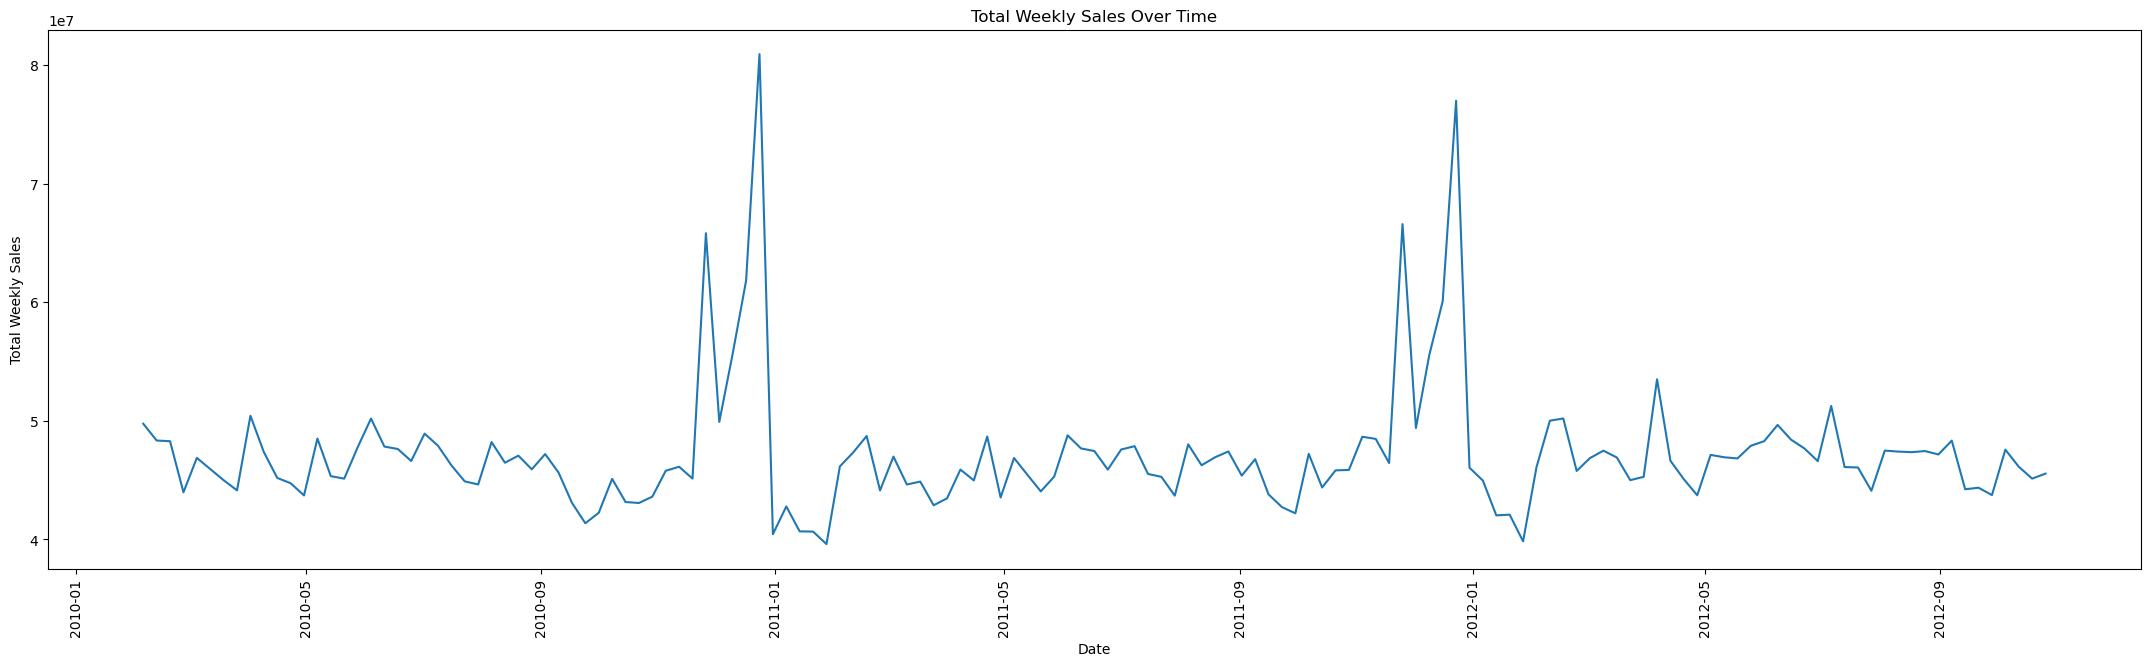

In [6]:
# df1 = df.groupby('date', as_index=False)['weekly_sales'].sum()
ts = (df.groupby('date', as_index=False)['weekly_sales'].sum().sort_values('date'))
plt.figure(figsize=(27,7))
plt.plot(ts['date'], ts['weekly_sales'])
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.title('Total Weekly Sales Over Time')
plt.xticks(rotation =90)
plt.show()

* this is time-series data with dependency.
* Total weekly sales exhibit strong annual seasonality and temporal dependence, confirming the data as time-series.

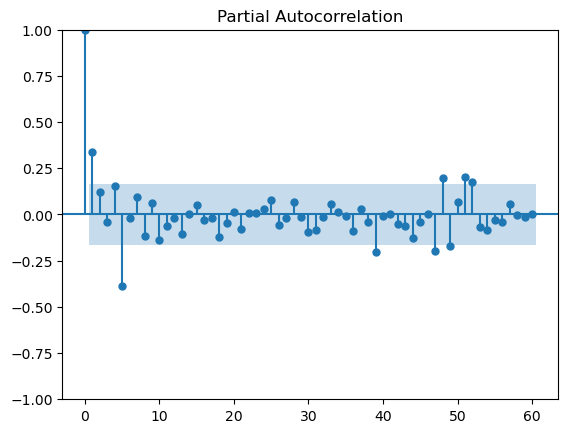

In [7]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(ts['weekly_sales'], lags=60, method='ywm')
plt.title('Partial Autocorrelation')
plt.show()

PACF shows a strong spike at lag 1, indicating a dominant AR(1) structure, with a mild seasonal autoregressive effect around lag 52.


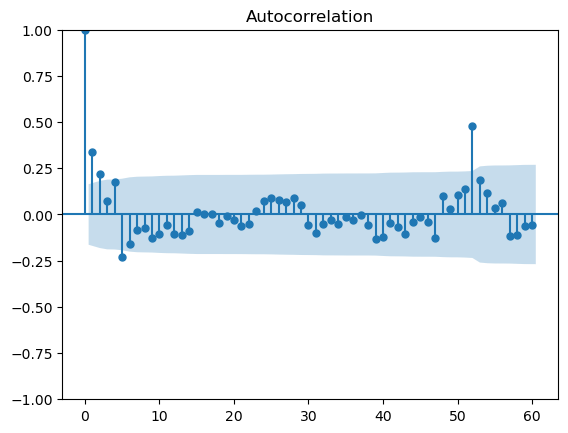

In [8]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(ts['weekly_sales'], lags=60)
plt.show()

The ACF plot shows significant short-term autocorrelation (lags 1–3) and a strong spike at lag 52, indicating annual seasonality.
This confirms that weekly sales are time-dependent and seasonally driven.

In [10]:
df.head()

,store,dept,date,weekly_sales,isholiday,type,size,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,log_weekly_sales
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,10.123647
277665,29,5,2010-02-05,15552.08,False,B,93638,24.36,2.788,0.0,0.0,0.0,0.0,0.0,131.527903,10.064,9.652014
277808,29,6,2010-02-05,3200.22,False,B,93638,24.36,2.788,0.0,0.0,0.0,0.0,0.0,131.527903,10.064,8.071287
277951,29,7,2010-02-05,10820.05,False,B,93638,24.36,2.788,0.0,0.0,0.0,0.0,0.0,131.527903,10.064,9.289249
278094,29,8,2010-02-05,20055.64,False,B,93638,24.36,2.788,0.0,0.0,0.0,0.0,0.0,131.527903,10.064,9.906316


In [11]:
ts.head()

,date,weekly_sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [12]:
from statsmodels.tsa.stattools import adfuller

# assuming you already created ts with columns: ['date','weekly_sales']
y = ts['weekly_sales'].dropna()

adf_stat, p_value, used_lags, n_obs, crit_values, icbest = adfuller(y, autolag='AIC')

print("ADF Statistic:", adf_stat)
print("p-value:", p_value)
print("Used lags:", used_lags)
print("Number of observations:", n_obs)
print("Critical Values:")
for k, v in crit_values.items():
    print(f"   {k}: {v}")

ADF Statistic: -5.908297957186332
p-value: 2.675979158986058e-07
Used lags: 4
Number of observations: 138
Critical Values:
   1%: -3.47864788917503
   5%: -2.882721765644168
   10%: -2.578065326612056


* If ADF statistic < critical value → reject unit root
* If p-value < 0.05 → reject unit root
* The null hypothesis of a unit root is rejected. The weekly sales series is stationary.
* ADF test confirms that the aggregated weekly sales series is stationary.

In [13]:
ts['date'] = pd.to_datetime(ts['date'])
ts = ts.sort_values('date')
ts = ts.set_index('date')

In [14]:
ts = ts.asfreq('W-FRI')
ts['weekly_sales'] = ts['weekly_sales'].fillna(0)

In [16]:
y = ts['weekly_sales']

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose
y = y.asfreq('7d')
decomposition = seasonal_decompose(y, model = 'additive',period=52)

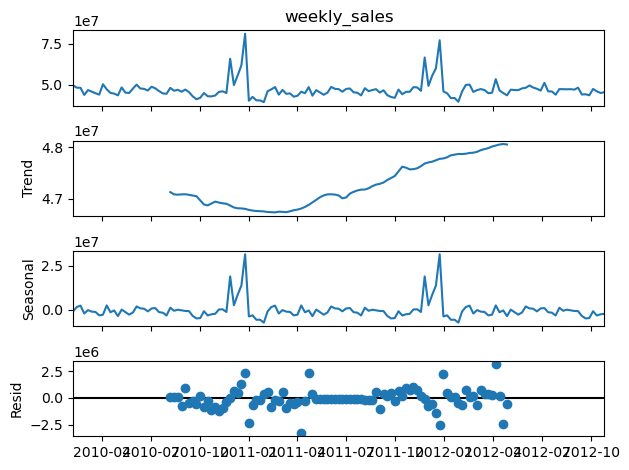

In [18]:
decomposition.plot()
plt.tight_layout()
plt.show()

In [20]:
y = ts['weekly_sales']

In [21]:
split = int(len(y) * 0.8)
train = y.iloc[:split]
test  = y.iloc[split:]

In [22]:

# Trend → d
# PACF → p
# ACF → q
# Summary → simplify
# Decomposition → seasonal model
# Observation	d
# No trend	0
# Clear linear / smooth trend	1
# Strong nonlinear trend	2 (rare)
# p = lag after which PACF cuts off
# q = lag after which ACF cuts off

In [23]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(2, 1, 1))
model_fit = model.fit()

model_fit.summary()

C:\Users\patid\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\patid\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           weekly_sales   No. Observations:                  114
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -1926.668
Date:                Tue, 03 Feb 2026   AIC                           3861.336
Time:                        21:57:32   BIC                           3872.246
Sample:                    02-05-2010   HQIC                          3865.763
                         - 04-06-2012                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4443      0.084      5.304      0.000       0.280       0.608
ar.L2          0.1003      0.084      1.192      0.233      -0.065       0.265
ma.L1         -0.9710      0.061    -16.040      0.000      -1.090      -0.852
sigma2      3.618e+13   1.54e-15   2.34e+28      0.000    3.62e+13    3.62e+13
===================================================================================
Ljung-Box (L1) (Q):                   0.72   Jarque-Bera (JB):               258.58
Prob(Q):                              0.40   Prob(JB):                         0.00
Heteroskedasticity (H):               2.82   Skew:                             0.90
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.45e+43. Standard errors may be unstable.
"""

if ar.L2 p-value is > 0.05 → AR(2) is not needed → reduce p to 1

if seasonality exists (your decomposition shows yearly spikes) → go SARIMA with s=52

In [24]:
from statsmodels.tsa.arima.model import ARIMA

arima = ARIMA(train, order=(1, 1, 1))  # simplified from (2,1,1)
arima_fit = arima.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           weekly_sales   No. Observations:                  114
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1927.340
Date:                Tue, 03 Feb 2026   AIC                           3860.680
Time:                        21:57:37   BIC                           3868.862
Sample:                    02-05-2010   HQIC                          3864.000
                         - 04-06-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4594      0.092      4.981      0.000       0.279       0.640
ma.L1         -0.9649      0.050    -19.174      0.000      -1.064      -0.866
sigma2      3.783e+13    1.3e-15   2.92e+28      0.0

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

arima_fc = arima_fit.forecast(steps=len(test))

mae_arima = mean_absolute_error(test, arima_fc)
rmse_arima = np.sqrt(mean_squared_error(test, arima_fc))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

ARIMA MAE: 1826656.4024296617
ARIMA RMSE: 2331799.464712818


In [26]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) In-sample predictions on TRAIN (fitted values)
train_pred = arima_fit.predict(start=train.index[1], end=train.index[-1])  # d=1 so start from 2nd point

# align train series with predictions
train_actual = train.loc[train_pred.index]

mae_train = mean_absolute_error(train_actual, train_pred)
rmse_train = np.sqrt(mean_squared_error(train_actual, train_pred))

# 2) Out-of-sample forecast on TEST
test_fc = arima_fit.forecast(steps=len(test))
test_fc.index = test.index  # ensure same index

mae_test = mean_absolute_error(test, test_fc)
rmse_test = np.sqrt(mean_squared_error(test, test_fc))

print("ARIMA Train MAE:", mae_train)
print("ARIMA Train RMSE:", rmse_train)
print("ARIMA Test  MAE:", mae_test)
print("ARIMA Test  RMSE:", rmse_test)

print("Overfit ratio (RMSE_test / RMSE_train):", rmse_test / rmse_train)

ARIMA Train MAE: 3636563.274116628
ARIMA Train RMSE: 6190642.536906006
ARIMA Test  MAE: 1826656.4024296617
ARIMA Test  RMSE: 2331799.464712818
Overfit ratio (RMSE_test / RMSE_train): 0.37666517664549537


In [27]:
# to detect overfitting walk forward method industry graded
from sklearn.metrics import mean_squared_error

def walk_forward_rmse(series, order=(1,1,1), train_size=0.8):
    split = int(len(series) * train_size)
    train, test = series.iloc[:split], series.iloc[split:]

    history = list(train)
    preds = []

    for t in range(len(test)):
        model = ARIMA(history, order=order)
        fit = model.fit()
        yhat = fit.forecast(steps=1)[0]
        preds.append(yhat)
        history.append(test.iloc[t])

    rmse = np.sqrt(mean_squared_error(test, preds))
    return rmse

rmse_wf = walk_forward_rmse(y, order=(1,1,1))
print("Walk-forward RMSE:", rmse_wf)

Walk-forward RMSE: 1876805.4428045882


Fit SARIMA (recommended for your data)

Your decomposition shows yearly seasonality (period=52). ARIMA can’t model that properly.
SARIMA adds seasonal terms: (P, D, Q, s).

Start with the most common baseline:

seasonal period s = 52 (weekly → yearly)

seasonal differencing D = 1 when yearly seasonality is strong

In [28]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima.fit()
print(sarima_fit.summary())

C:\Users\patid\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                       weekly_sales   No. Observations:                  114
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                -112.408
Date:                            Tue, 03 Feb 2026   AIC                            234.817
Time:                                    21:57:49   BIC                            234.546
Sample:                                02-05-2010   HQIC                           231.474
                                     - 04-06-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4030      7.107     -0.057      0.955     -14.333      13.527
ma.L1         -0.9235      3.787   

In [29]:
sarima_fc = sarima_fit.forecast(steps=len(test))

mae_sarima = mean_absolute_error(test, sarima_fc)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_fc))

print("SARIMA MAE:", mae_sarima)
print("SARIMA RMSE:", rmse_sarima)

SARIMA MAE: 1703732.5498642025
SARIMA RMSE: 2129749.983795624


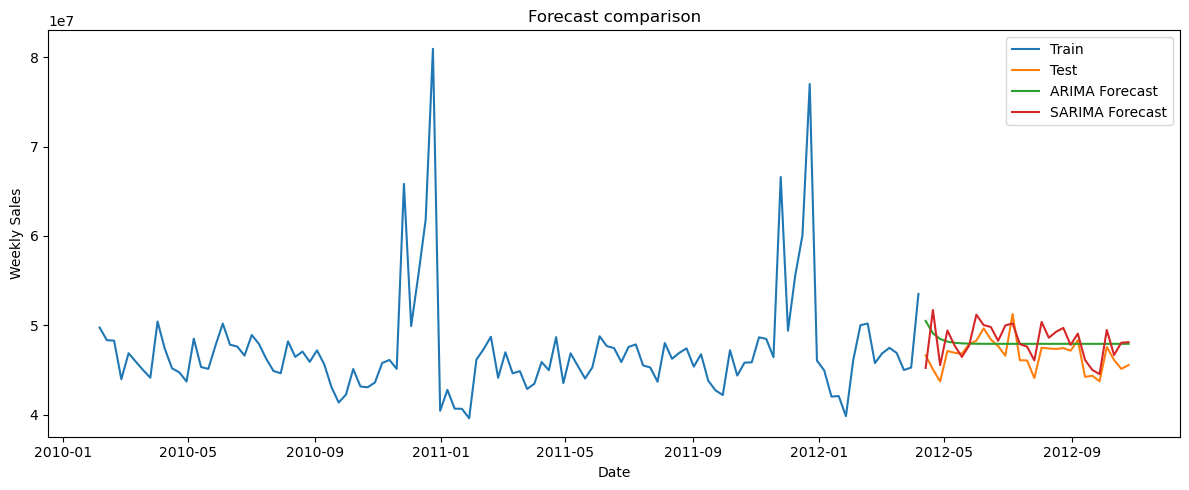

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, arima_fc, label="ARIMA Forecast")
plt.plot(test.index, sarima_fc, label="SARIMA Forecast")
plt.title("Forecast comparison")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()

Choose final model + refit on full data
After selecting best model (usually SARIMA), refit on all available data before predicting the future
ARIMA understands trend,ARIMA ignores seasonality
SARIMA captures trend + seasonality,This is what we want for weekly sales
want to extend project further Add exogenous variables (SARIMAX)

In [31]:
final_model = SARIMAX(
    y,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

C:\Users\patid\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [32]:
# Predict future (your “price” / sales forecast)

In [33]:
#predict next 12 weeks:
n_steps = 12
future_forecast = final_model.forecast(steps=n_steps)

future_forecast

2012-11-02    4.945676e+07
2012-11-09    4.929436e+07
2012-11-16    4.728163e+07
2012-11-23    6.744777e+07
2012-11-30    5.027286e+07
2012-12-07    5.643445e+07
2012-12-14    6.099424e+07
2012-12-21    7.795424e+07
2012-12-28    4.679205e+07
2013-01-04    4.577932e+07
2013-01-11    4.286499e+07
2013-01-18    4.292124e+07
Freq: W-FRI, Name: predicted_mean, dtype: float64

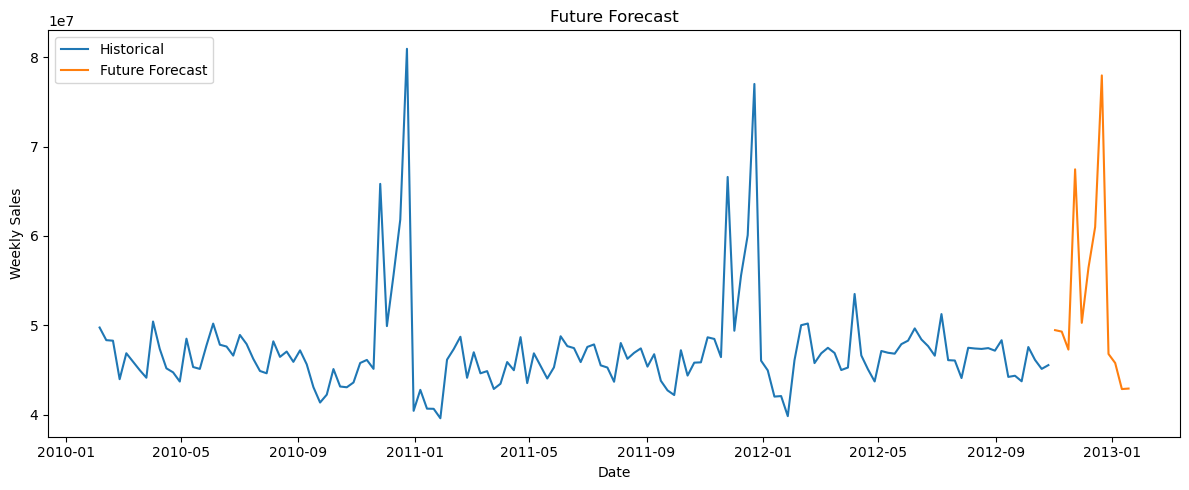

In [34]:
plt.figure(figsize=(12,5))
plt.plot(y.index, y, label="Historical")
plt.plot(future_forecast.index, future_forecast, label="Future Forecast")
plt.title("Future Forecast")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()